Here, we apply normalization/dimensionality reduction/batch correections to the counts matrix:

In [1]:
import time
import os

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.decomposition import PCA

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load the raw counts matrix (already filtered for low QC cells):

In [ ]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

Normalize and identify HVGs:

In [5]:
%%time
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

CPU times: user 59.8 s, sys: 1.3 s, total: 1min 1s
Wall time: 1min 1s


In [6]:
adata

AnnData object with n_obs × n_vars = 734650 × 16227
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition', 'drug_target', 'drug_moa'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

Run PCA: 

In [ ]:
%%time
sc.tl.pca(
    data = adata, 
    zero_center = True, # use cov matrix
    mask_var = 'highly_variable', # use hvgs
    random_state = seed)

Identify a rank from the variance ratio:

In [ ]:
n_pcs = pp._compute_elbow(adata, curve='convex', direction='decreasing')
adata.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [ ]:
adata.write_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

## Covariate Associations

Use the first n_pcs to understand which covariates are most associated with PC variance:

In [5]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [6]:
# r2_df_linear = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'linear', 
#     latent_label = 'pca',
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df_nl = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'nonlinear', 
#     latent_label = 'pca',
#     n_cores = n_cores, 
#     seed = seed
# )

# # r2_df = pd.concat([r2_df_linear, r2_df_nl])
# # r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_pc_associations.csv'))

# r2_df = pd.read_csv(os.path.join(data_path, 'processed', author + '_geneexpr_pc_associations.csv'), 
#                    index_col = 0)

Visualize, rank-ordered by median value:

/tmp/ipykernel_3741985/2630786968.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_3741985/2630786968.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

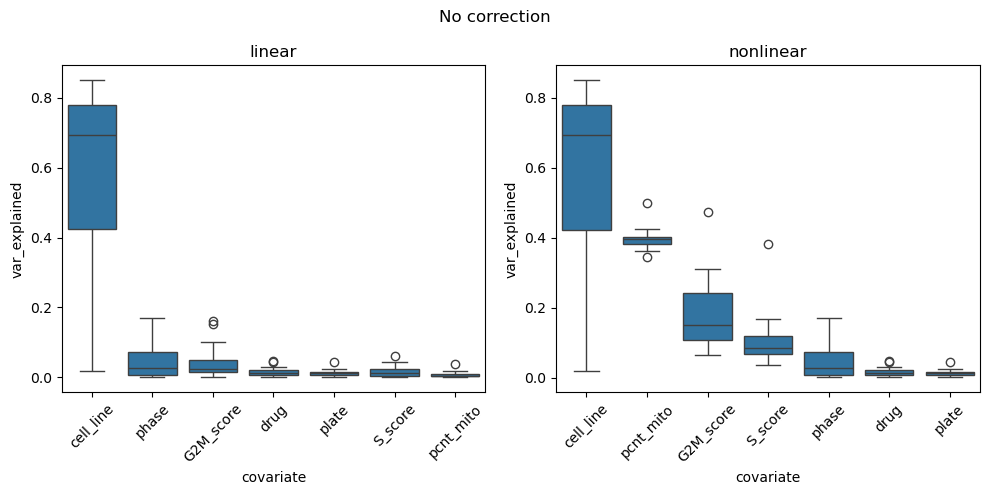

In [7]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('No correction')
fig.tight_layout()
;

Since cell line is strongly dominant, let's also see what these boxplots look like without that: 

/tmp/ipykernel_3741985/2726537125.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_3741985/2726537125.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

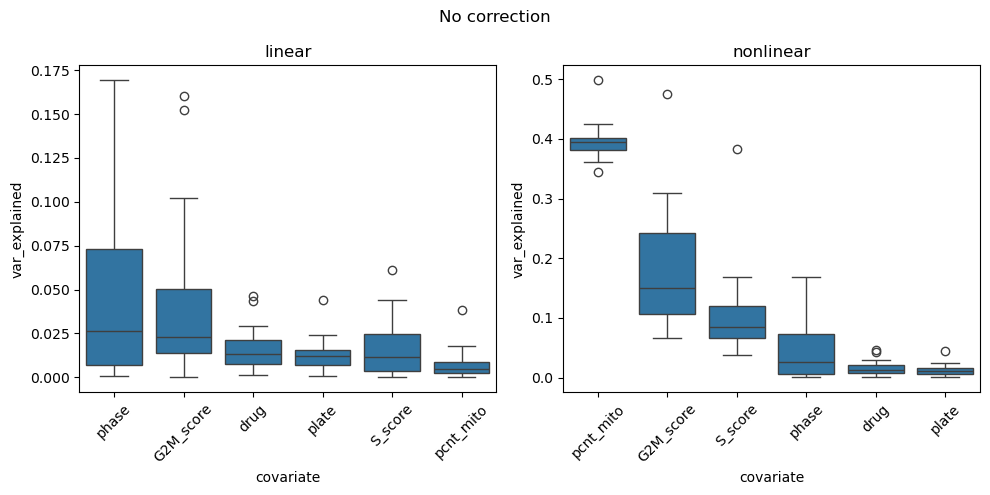

In [8]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type', 'cell_line']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('No correction, disregard cell line')
fig.tight_layout()
;

Median PC var explained values:

In [9]:
pd.melt(r2_df.set_index('PC'), id_vars='model_type', var_name='covariate').groupby(['model_type', 'covariate']).median()



value
model_type covariate          
linear     G2M_score  0.023187
           S_score    0.011637
           cell_line  0.694270
           drug       0.013358
           pcnt_mito  0.004587
           phase      0.026285
           plate      0.011880
nonlinear  G2M_score  0.150066
           S_score    0.085065
           cell_line  0.694270
           drug       0.013358
           pcnt_mito  0.394836
           phase      0.026285
           plate      0.011879

### Cell Cycle Deep Dive

Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.

In [10]:
pairs = [
    ('G2M_score', 'S_score'),
    ('phase', 'G2M_score'),
    ('phase', 'S_score'),
]

for x, y in pairs:
    x_vals = adata.obs[x].cat.codes if adata.obs[x].dtype.name == 'category' else adata.obs[x]
    y_vals = adata.obs[y].cat.codes if adata.obs[y].dtype.name == 'category' else adata.obs[y]
    
    stat, pval = stats.spearmanr(x_vals, y_vals)
    print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")


Spearman(G2M_score vs S_score): ρ = 0.571, p = 0
Spearman(phase vs G2M_score): ρ = 0.756, p = 0
Spearman(phase vs S_score): ρ = 0.530, p = 0


Let's use a PC component that captures all 3 metrics:

In [11]:
phase_dummies = pd.get_dummies(adata.obs['phase'], prefix='phase').astype(int)
X = pd.concat([adata.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

pca_mod = PCA(n_components=1, random_state = seed)
pca_mod.fit(X) # fit to all 3 metrics

var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

cell_cycle_pc1 = pca_mod.transform(X)
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

Variance explained by PC1 of aggregated cell cycle metrics: 70.677%


In [12]:
pairs = [
    ('G2M_score', 'cell_cycle_PC1'),
    ('phase', 'cell_cycle_PC1'),
    ('S_score', 'cell_cycle_PC1'),
]

for x, y in pairs:
    x_vals = adata.obs[x].cat.codes if adata.obs[x].dtype.name == 'category' else adata.obs[x]
    y_vals = adata.obs[y].cat.codes if adata.obs[y].dtype.name == 'category' else adata.obs[y]
    
    stat, pval = stats.spearmanr(x_vals, y_vals)
    print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")


Spearman(G2M_score vs cell_cycle_PC1): ρ = 0.981, p = 0
Spearman(phase vs cell_cycle_PC1): ρ = 0.801, p = 0
Spearman(S_score vs cell_cycle_PC1): ρ = 0.625, p = 0


Looks like the PC well accounts for all 3 cell cycle metrics, atleast linearly. So, we will use this as our cell cycle covariate.

## Covariate correction

In [13]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


In [14]:
plate_dummies = pd.get_dummies(adata.obs['plate'], prefix='plate').astype(float)
for col in plate_dummies.columns:
    adata.obs[col] = plate_dummies[col]
    
batch_keys = ['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist()

### Linear 

Remove confounding effects using as imple linear regression

only run on HVGs for compute time:

In [7]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))


# adata_hvg = adata[:, adata.var.highly_variable].copy()
# sc.pp.regress_out(
#     adata_hvg, 
#     keys=['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist(),
#     n_jobs = n_cores)
# adata_hvg.write_h5ad(os.path.join(data_path, 'interim', 'temp_regressed_counts.h5ad'))
adata_hvg = sc.read_h5ad(os.path.join(data_path, 'interim', 'temp_regressed_counts.h5ad'))


Get the new PCA:

In [8]:
%%time
sc.tl.pca(
    data = adata_hvg, 
    zero_center = True, # use cov matrix
    mask_var = 'highly_variable', # use hvgs -- all true in this case, already filtered
    random_state = seed)

CPU times: user 34min 40s, sys: 3.38 s, total: 34min 44s
Wall time: 2min 56s


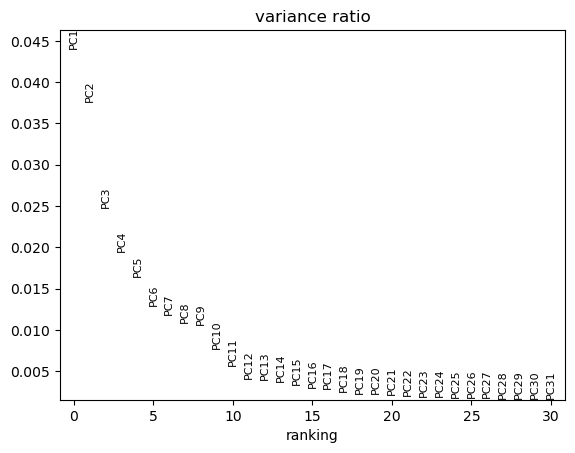

The elbow was automatically identified at PC 12


In [9]:
n_pcs = pp._compute_elbow(adata_hvg, curve='convex', direction='decreasing')
adata_hvg.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata_hvg)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [4]:

# r2_df_linear = pp.latent_association(
#     adata = adata_hvg,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'linear', 
#     latent_label = 'pca', 
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df_nl = pp.latent_association(
#     adata = adata_hvg,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'nonlinear', 
#     latent_label = 'pca', 
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df = pd.concat([r2_df_linear, r2_df_nl])
# r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_linearcorrected_pc_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', 
                                 author + '_geneexpr_linearcorrected_pc_associations.csv'), 
                   index_col = 0)

Visualize and rank-order by median:

/tmp/ipykernel_919276/1220322423.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_919276/1220322423.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

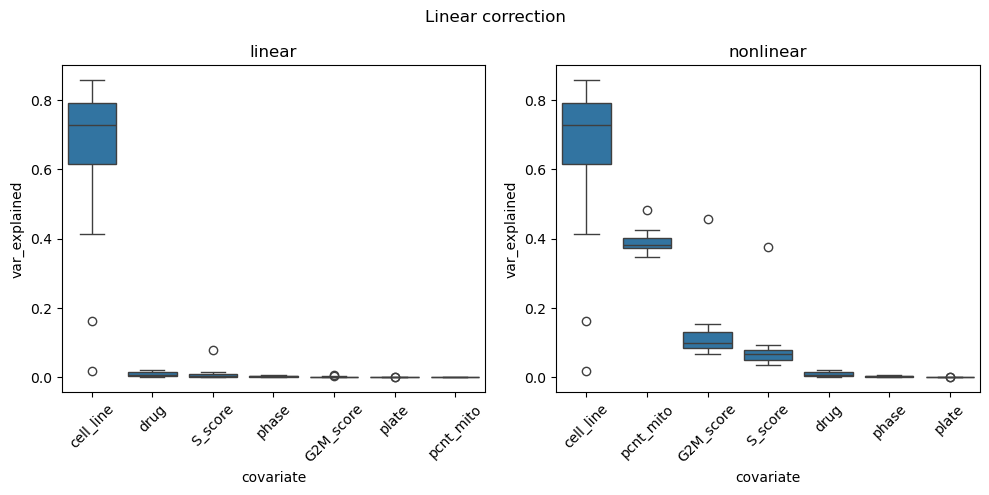

In [5]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('Linear correction')
fig.tight_layout()
;

/tmp/ipykernel_919276/2386106168.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_919276/2386106168.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

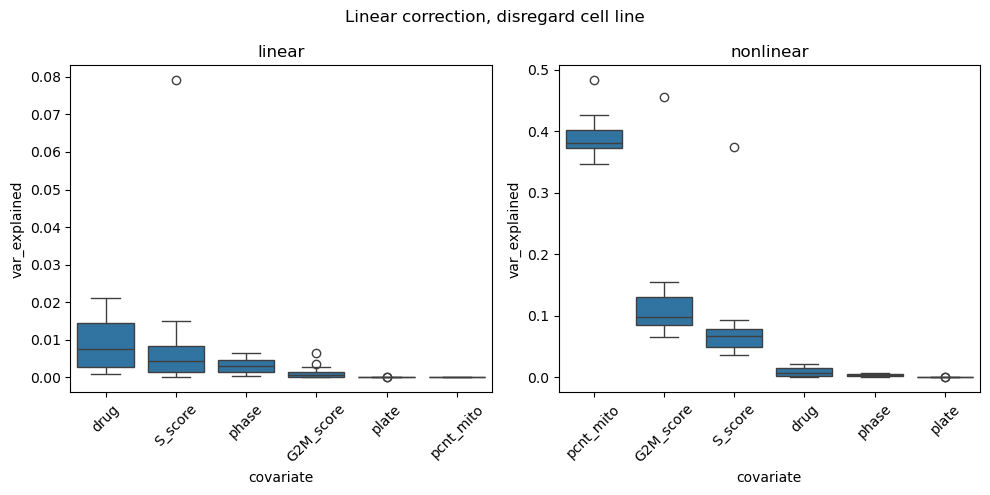

In [11]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type', 'cell_line']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('Linear correction, disregard cell line')
fig.tight_layout()
;

Looks like the linear correctino brought drug up to the highest other than cell line, though it's still very small. It didn't really do much for non-linear confounding. Thus, linear correction won't work well. 

### Nonlinear:

Remove confounding effects using scVI

# PLS-DA and UMAP

In [33]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [34]:
import Tahoe_utils as Tu
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import umap
from tqdm import trange

In [35]:
models, assessment, X_pls = Tu.pls_da(adata,
       n_components = 5,
       control_confounders = ['cell_line'],
          assess = True,
          return_components = True,
          seed = 888, 
          enc_X = None, 
          enc_Y = None)
pls_model = models['pls_model']

# import json
# with open("trash_norm.json", "w") as f:
#     json.dump(assessment, f, indent=4)

In [36]:
test.__dict__.keys()

dict_keys(['categories', 'sparse_output', 'dtype', 'handle_unknown', 'drop', 'min_frequency', 'max_categories', 'feature_name_combiner', '_infrequent_enabled', 'n_features_in_', 'categories_', '_drop_idx_after_grouping', 'drop_idx_', '_n_features_outs'])

In [37]:
assessment

{'n_components': 5,
 'accuracy': 0.10652283400258626,
 'explained_y': 0.018939023884408823}

In [38]:
proj_df = pd.DataFrame(X_pls)
proj_df.columns = ['PLS{}'.format(i+1) for i in range(proj_df.shape[1])]

res = []
for cov_ in ['drug', 'cell_line']:
    cov = adata.obs[cov_].astype(str)
    enc = OneHotEncoder(drop="first", sparse_output=False)
    cov_encoded = enc.fit_transform(cov.values.reshape(-1, 1))

    r2_scores = []
    for pls_idx in trange(proj_df.shape[1]):
        y = proj_df.iloc[:, pls_idx]
        model = LinearRegression().fit(cov_encoded, y)
        r2 = model.score(cov_encoded, y)
        r2_scores.append({"PLS": pls_idx + 1, "R2": r2})

    r2_df = pd.DataFrame(r2_scores)
    r2_df['covariate'] = cov_
    res.append(r2_df)
    
r2_df = pd.concat(res, axis=0, ignore_index=True)
# r2_df.to_csv('trash_norm.csv')

100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  4.79it/s]


In [40]:
r2_df.groupby('covariate').mean()

,PLS,R2
covariate,,
cell_line,3.0,0.269154
drug,3.0,0.128785


In [41]:
r2_df.groupby('covariate').median()

,PLS,R2
covariate,,
cell_line,3.0,0.302535
drug,3.0,0.117300


Text(0.5, 0, 'Covariate')

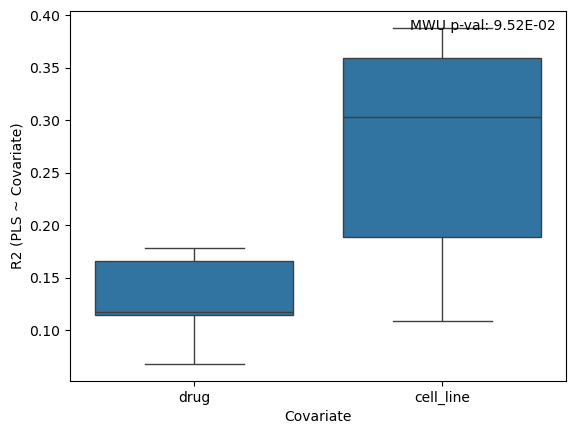

In [42]:
fig, ax = plt.subplots()

pval = stats.mannwhitneyu(r2_df[r2_df.covariate == 'drug'].R2, 
                  r2_df[r2_df.covariate == 'cell_line'].R2).pvalue
sns.boxplot(data = r2_df, x = 'covariate', y = 'R2', ax = ax)

ax.annotate(
    "MWU p-val: {:.2E}".format(pval),
    xy=(0.98, 0.98),
    xycoords="axes fraction",
    ha="right",
    va="top"
)

ax.set_ylabel('R2 (PLS ~ Covariate)')
ax.set_xlabel('Covariate')
# ax.set_title('Top 2 PLS')

In [43]:
proj_df['drug'] = adata.obs.drug.values
proj_df['cell_line'] = adata.obs.cell_line.values
proj_df['condition'] = proj_df.drug.astype(str) + '^' + proj_df.cell_line.astype(str)

''

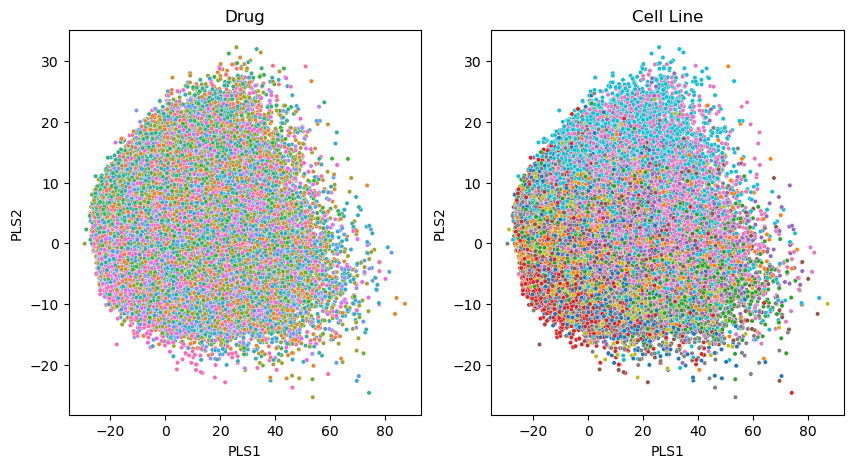

In [44]:
# subset to 20% of the dataset
# n_per_condition = int(np.round(proj_df.drug.value_counts().min() * 0.2))

# # Subsample indices evenly per condition
# sampled_indices = (
#     proj_df.groupby('drug')
#     .sample(n=n_per_condition, random_state=seed)
#     .index
# )

n_per_condition = int(np.round(adata.obs['condition'].value_counts().min() * 0.2))

# Subsample indices evenly per condition
sampled_indices = (
    proj_df.groupby('condition')
    .sample(n=n_per_condition, random_state=seed)
    .index
)

# shuffle
np.random.seed(seed)
sampled_indices=np.random.permutation(sampled_indices)

viz_df = proj_df.loc[sampled_indices, :].copy()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;

In [45]:
%%time
umap_model = umap.UMAP(n_neighbors=15, 
                    n_components=2,
                    metric='euclidean', 
                    target_metric='categorical', 
                    random_state = seed)
umap_model.fit(X_pls,
               adata.obs['drug'].cat.codes.values)
embedding = umap_model.transform(X_pls)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


CPU times: user 57min 20s, sys: 7min 50s, total: 1h 5min 10s
Wall time: 17min 29s


''

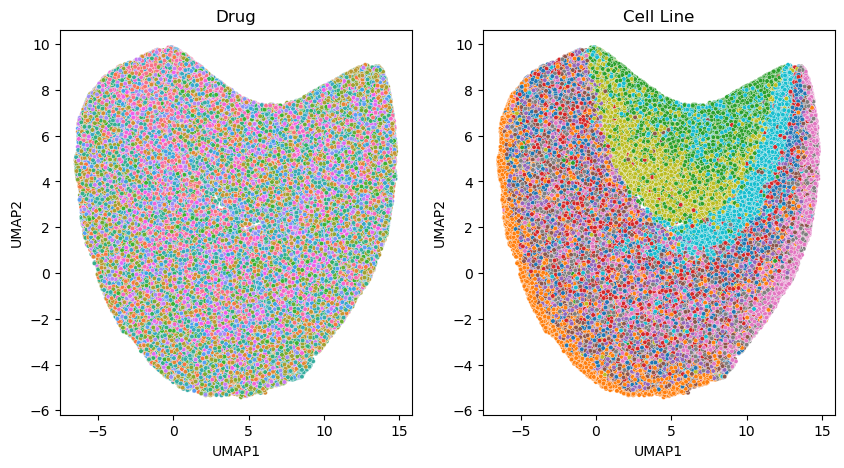

In [46]:
viz_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
viz_df['drug'] = adata.obs.drug.astype(str).values
viz_df['cell_line'] = adata.obs.cell_line.astype(str).values
viz_df = viz_df.loc[sampled_indices, :]

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;